In [1]:
#INSTALL
%pip install pandas
%pip install seaborn
%pip install spacy
%pip install fr_core_news_sm
%pip install scikit-learn

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.7 MB 7.5 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.7 MB 8.8 MB/s eta 0:00:01
   ----------------------- ---------------- 5.8/9.7 MB 9.8 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.7 MB 10.3 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 10.3 MB/s  0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ------- -------------------------------- 2.4/12.3 MB 12.2 MB/s eta 0:00:01
   --------------- ------------------------ 4.7/12.3 MB 11.9 MB/s eta 0:00:01
   ---------------------- ----------------- 7.1/12.3 MB 11.8 MB/s eta 0:00:01
   ------------------------------- -------- 9.7/12.3 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.3 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 11.7 MB/s  0:00:01

   -----------

In [2]:
#IMPORT
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import spacy
import random
from spacy.lang.fr.stop_words import STOP_WORDS as fr_stop
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [3]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

stop_words_cuisine = [ # Générés par Gemini
    # --- Unités et Mesures ---
    "g", "gr", "gramme", "grammes", "kg", "kilogramme",
    "l", "litres", "litre", "ml", "cl", "dl",
    "cuillère", "cuillères", "c.à.s", "c.à.c", "cas", "cac",
    "pincée", "pincées", "tasse", "tasses", "verre", "verres",
    "poignée", "tranche", "tranches", "morceau", "morceaux",
    "bouteille", "sachet", "boîte", "pot", "paquet", "brin", 
    "feuille", "feuilles", "gousse", "gousses", "°","c", "mn",
    
    # --- Verbes d'action (Instructions fréquentes) ---
    "ajouter", "ajoutez", "mélanger", "mélangez", "remuer",
    "verser", "versez", "incorporer", "couper", "coupez",
    "hacher", "éplucher", "cuire", "laisser", "mettre", "mettez",
    "servir", "disposer", "saupoudrer", "garnir", "préparer",
    "chauffer", "préchauffer", "bouillir", "mijoter", "réserver",
    "laver", "égoutter", "battre", "fouetter", "étaler", "faire",
    
    # --- Adjectifs / États ---
    "chaud", "froide", "tiède", "bouillant", 
    "fondu", "haché", "râpé", "entier", "entière",
    "fin", "fine", "épais", "gros", "petit",
    "frais", "fraîche", "sec", "sèche",
    
    # --- Ingrédients "neutres" (souvent exclus de l'analyse thématique) ---
    # À retirer de cette liste si vous voulez garder tous les ingrédients
    "sel", "poivre", "eau", "huile", "beurre", "sucre", "farine",
    
    # --- Mots de liaison temporels ---
    "puis", "ensuite", "enfin", "pendant", "environ", "minutes", "min", 
    "heure", "heures", "seconde", "secondes", "avant", "après",

    # --- Autres ---
    " ", "1/2","bien"
]

stops = list(set(list(fr_stop)+stop_words_cuisine))

X_train = train_df["titre"] + " " + train_df["ingredients"] + " " + train_df["recette"]
X_test = test_df["titre"] + " " + test_df["ingredients"] + " " + test_df["recette"]
Y_train = train_df["type"]
Y_test = test_df["type"]

In [4]:
# Function to print results
def get_results(actual,predictions) :
    print(f"Resultat (Micro-F1) : {f1_score(actual, predictions, average='micro'):.2f}")
    print(f"Résultat (Macro-F1) : {f1_score(actual, predictions, average='macro'):.2f}")
    print(f"Résultat (Accuracy) : {accuracy_score(actual, predictions):.2f}")

    classes = sorted(actual.unique())
    print(classes)
    print(f"Résultat (F1 par classe) : {f1_score(actual, predictions, average=None)}")
    confusion = confusion_matrix(actual, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion, 
                annot=True,
                fmt='d',
                xticklabels=classes, 
                yticklabels=classes)
    plt.xlabel("Prédiction")
    plt.ylabel("Vraie valeur")
    plt.show()

Resultat (Micro-F1) : 0.46
Résultat (Macro-F1) : 0.21
Résultat (Accuracy) : 0.46
['Dessert', 'Entrée', 'Plat principal']
Résultat (F1 par classe) : [0.         0.         0.63385827]


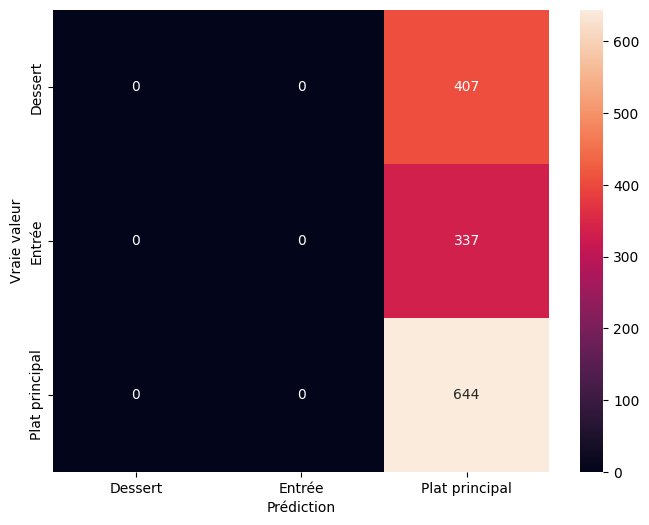

Resultat (Micro-F1) : 0.33
Résultat (Macro-F1) : 0.32
Résultat (Accuracy) : 0.33
['Dessert', 'Entrée', 'Plat principal']
Résultat (F1 par classe) : [0.31506849 0.28716645 0.36657682]


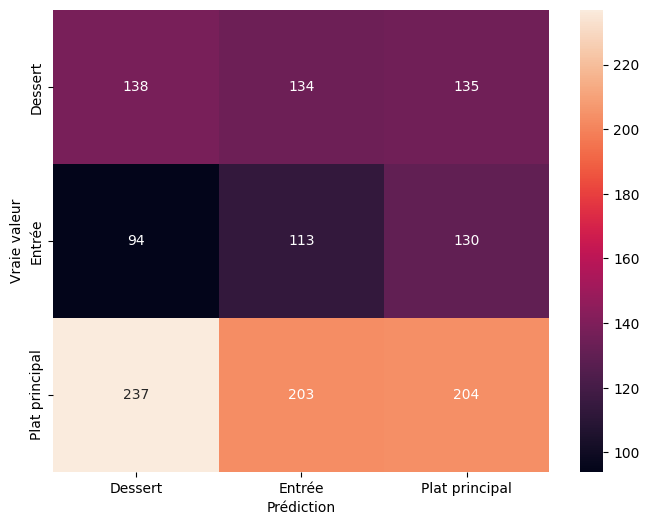

In [5]:
# Baseline

randomState = 42
random.seed(randomState)

def aleatoire(text):
  possibilities = ["Entrée", "Plat principal", "Dessert"]
  r = random.randint(0,2)
  return possibilities[r]


def majoritaire(text):
  return "Plat principal"

predictions = Y_test.apply(majoritaire)
get_results(Y_test, predictions)

predictions = Y_test.apply(aleatoire)
get_results(Y_test, predictions)

c:\Users\ewenh\Main_Doc\M1\S2\TAL\projet\tal_project\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['neuf', 'qu', 'quelqu'] not in stop_words.
  warnings.warn(


Resultat (Micro-F1) : 0.80
Résultat (Macro-F1) : 0.74
Résultat (Accuracy) : 0.80
['Dessert', 'Entrée', 'Plat principal']
Résultat (F1 par classe) : [0.93995381 0.42920354 0.83813443]


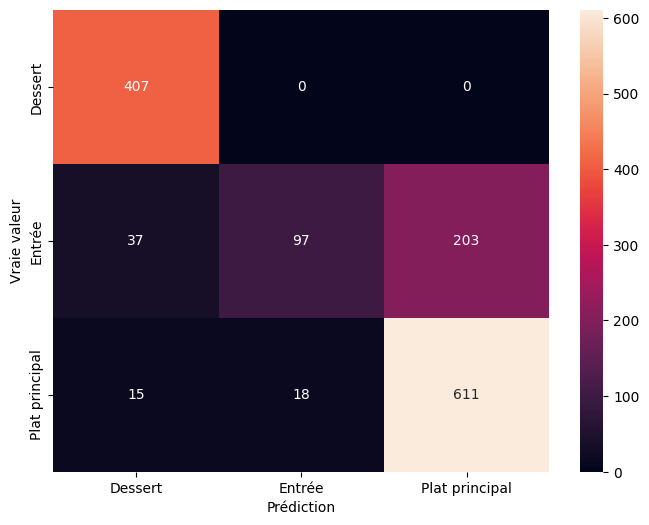

In [6]:
# Méthode A : TF-IDF + Naive Bayes
model = Pipeline([  # sequentially apply a list of transformers
    ('tfidf', TfidfVectorizer(stop_words=stops, lowercase=True)),   # TF-IDF to preprocess the data
    ('cnb', ComplementNB()) # Naive Bayes to predict the class
])

model.fit(X_train, Y_train)

predictions = model.predict(X_test)

get_results(Y_test, predictions)

Nous remarquons que les desserts sont plutôt bien classifiés mais que notre modèle a plus de difficultés à différencier les entrées et les plats principaux.

c:\Users\ewenh\Main_Doc\M1\S2\TAL\projet\tal_project\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['neuf', 'qu', 'quelqu'] not in stop_words.
  warnings.warn(


Resultat (Micro-F1) : 0.88
Résultat (Macro-F1) : 0.87
Résultat (Accuracy) : 0.88
['Dessert', 'Entrée', 'Plat principal']
Résultat (F1 par classe) : [0.98663426 0.73584906 0.87471526]


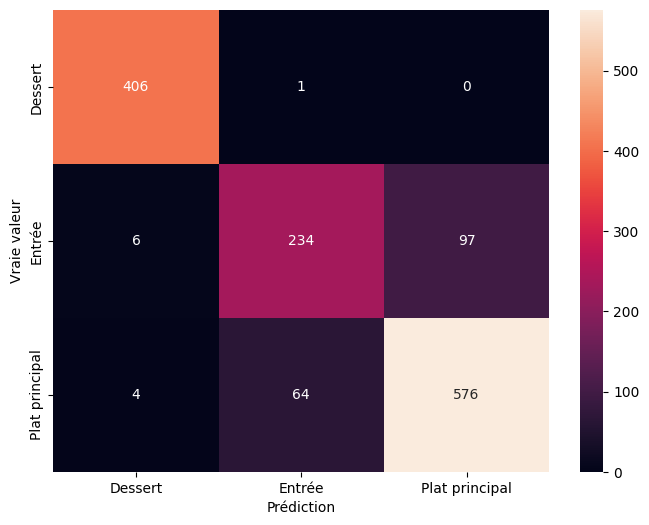

In [7]:
# Méthode B-1 :  TF-IDF + 2-grammes + SVM
model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=stops, lowercase=True, ngram_range=(1,2))),
    ('svm', SVC(kernel='linear'))
])

model.fit(X_train, Y_train)
predictions = model.predict(X_test)
get_results(Y_test, predictions)

c:\Users\ewenh\Main_Doc\M1\S2\TAL\projet\tal_project\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['neuf', 'qu', 'quelqu'] not in stop_words.
  warnings.warn(


Resultat (Micro-F1) : 0.86
Résultat (Macro-F1) : 0.84
Résultat (Accuracy) : 0.86
['Dessert', 'Entrée', 'Plat principal']
Résultat (F1 par classe) : [0.98186215 0.68341709 0.86538462]


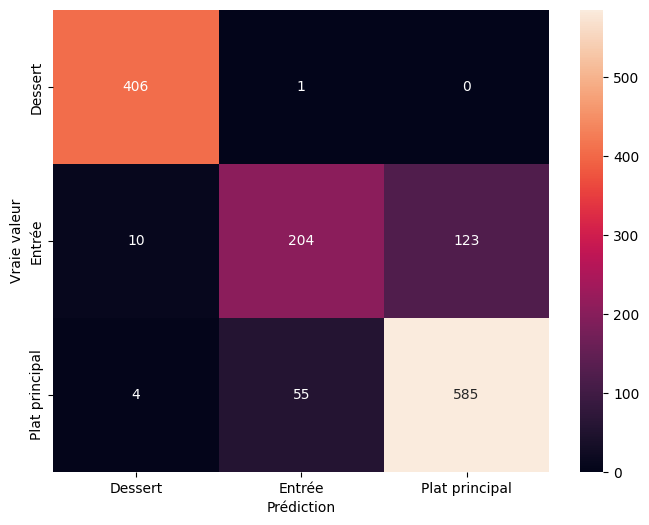

In [8]:
# Méthode B-2 :  TF-IDF + 2-grammes + logistic regression
model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=stops, lowercase=True, ngram_range=(1,2))),
    ('logreg', LogisticRegression(max_iter=1000))
])
model.fit(X_train, Y_train)
predictions = model.predict(X_test)
get_results(Y_test, predictions)

Méthode C : Nous avons enrichi le modèle en intégrant des variables numériques : le nombre d'ingrédients et la longueur du texte de la recette. Nous avons choisi de ne pas ajouter de filtrage sur les termes sucrés/salés car les modèles précédents parvenait déjà à isoler très efficacement les desserts des autres catégories (entrées et plats principaux).

c:\Users\ewenh\Main_Doc\M1\S2\TAL\projet\tal_project\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['neuf', 'qu', 'quelqu'] not in stop_words.
  warnings.warn(


Resultat (Micro-F1) : 0.88
Résultat (Macro-F1) : 0.87
Résultat (Accuracy) : 0.88
['Dessert', 'Entrée', 'Plat principal']
Résultat (F1 par classe) : [0.98663426 0.7327044  0.87623386]


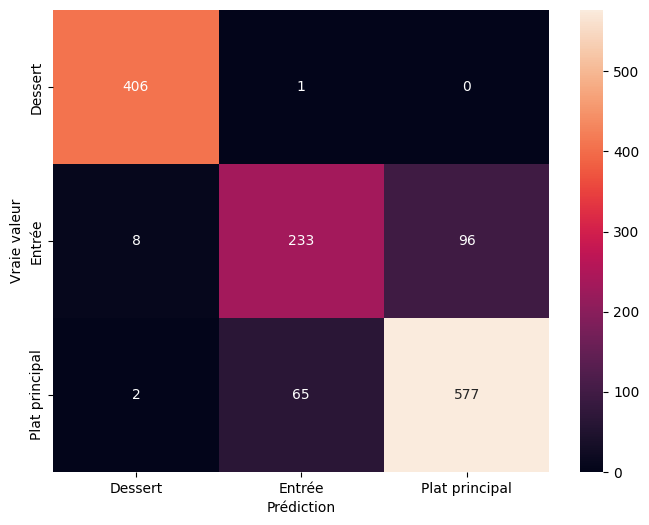

In [ ]:
# Méthode C : Modèle enrichi
X_train_3 = pd.DataFrame({
    "recette_complete": X_train,
    "nb_ingredients": train_df["ingredients"].apply(lambda x: len(x.split(" - "))),
    "length_recette": train_df["recette"].apply(lambda x: len(x))
})
X_test_3 = pd.DataFrame({
    "recette_complete": X_test,
    "nb_ingredients": test_df["ingredients"].apply(lambda x: len(x.split(" - "))),
    "length_recette": test_df["recette"].apply(lambda x: len(x))
})
Y_train= train_df["type"]
Y_test = test_df["type"]

model = Pipeline([
    ('features', ColumnTransformer([
        ('tfidf', TfidfVectorizer(stop_words=stops, lowercase=True), 'recette_complete',), # Nous obtenons un meilleur résultat sans les bi-grammes
        ('num', MinMaxScaler(), ['nb_ingredients', 'length_recette'])
    ])),
    (('logreg', LogisticRegression(max_iter=1000)))
])

model.fit(X_train_3, Y_train)
predictions = model.predict(X_test_3)
get_results(Y_test, predictions)

Nous obtenons un meilleur résultat avec ce modèle enrichi mais les résultats sont très proches.


# Analyse des résultats

#### Analyse Quantitative
Nous obtenons de très bons résultats pour les desserts. La confusion est faible avec les autres catégories car le vocabulaire spécifique.

En revanche, les entrées et les plats principaux sont plus souvent confondus. Avec un F1-score plus faible (0,73) pour les entrées et 85 erreurs de prédiction vers les plats, on voit que le modèle subit l'impact du déséquilibre : comme il a beaucoup plus d'exemples de "Plats" (classe majoritaire), il a tendance à y classer par défaut certaines entrées.

Le score global (0.88 de micro-F1, 0.87 de macro-f1) est satisfaisant, la grande majorité des plâts sont bien classifiés.

In [10]:
df_results = X_test_3.copy()
df_results['Vrai_Type'] = Y_test.values
df_results['Prediction'] = predictions

print("Exemples de bonnes prédictions :")
display(df_results[df_results['Vrai_Type'] == df_results['Prediction']].head(20))

print("\nExemples d'erreurs typiques :")
display(df_results[df_results['Vrai_Type'] != df_results['Prediction']].head(20))

Exemples de bonnes prédictions :


,recette_complete,nb_ingredients,length_recette,Vrai_Type,Prediction
0,Roulé à la confiture de lait - Pour la garnitu...,8,802,Dessert,Dessert
1,Croissants aux amandes - 250 g de farine - 1 p...,14,1482,Dessert,Dessert
2,Quinoa Phileas (aux légumes croquants et sauci...,15,2055,Plat principal,Plat principal
3,Magret de canard à la crème de mûre - 1 magret...,4,651,Plat principal,Plat principal
4,St-Jacques a la sauce aux huitres et aux asper...,8,833,Entrée,Entrée
5,Gâteau duo de chocolat et son coeur de petit b...,12,1338,Dessert,Dessert
6,Gratin de noix de Saint-Jacques aux petits lég...,9,1248,Plat principal,Plat principal
7,Succès au chocolat - 6 blancs d'oeufs - 250 g ...,13,1677,Dessert,Dessert
8,Fricassée de pintade fermière aux aromates - u...,10,638,Plat principal,Plat principal
9,Langouste sucrée/salée - 1 langouste d'environ...,10,1069,Plat principal,Plat principal



Exemples d'erreurs typiques :


,recette_complete,nb_ingredients,length_recette,Vrai_Type,Prediction
28,Cassolette de crevettes à la crème d'ail doux ...,8,577,Entrée,Plat principal
49,Salade de pâtes fraîches - 2 petites courgette...,10,922,Entrée,Plat principal
56,Tarte au thon et tomate facile - 1 pâte feuill...,7,598,Entrée,Plat principal
57,Chausson vichy au jambon - 1 pâte feuilletée -...,4,489,Entrée,Plat principal
65,Croquettes de jambon au fromage - 1 tranche de...,2,526,Entrée,Plat principal
70,Salade de pissenlit à la sauce tomate - 500 g ...,6,443,Entrée,Plat principal
80,Croustade marinière - une pâte feuilletée - 1 ...,7,516,Plat principal,Entrée
91,Tarte aux brocolis et au bleu - 1 pâte brisée ...,8,528,Entrée,Plat principal
97,Salade Tex-Mex - 3 belles escalopes de dinde -...,10,526,Entrée,Plat principal
102,Velouté de carotte au curcuma - 7 grosses caro...,7,604,Entrée,Plat principal


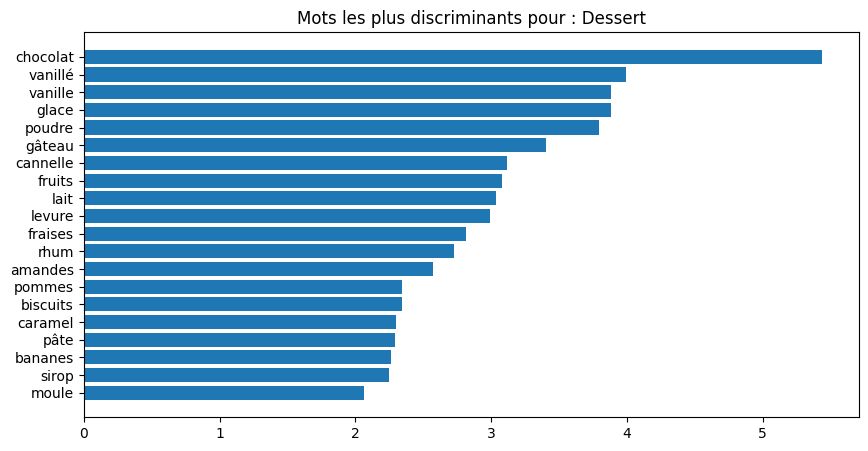

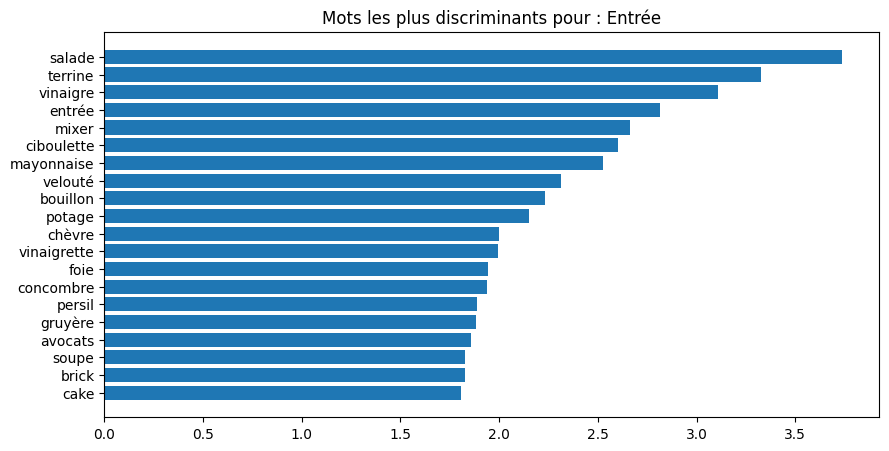

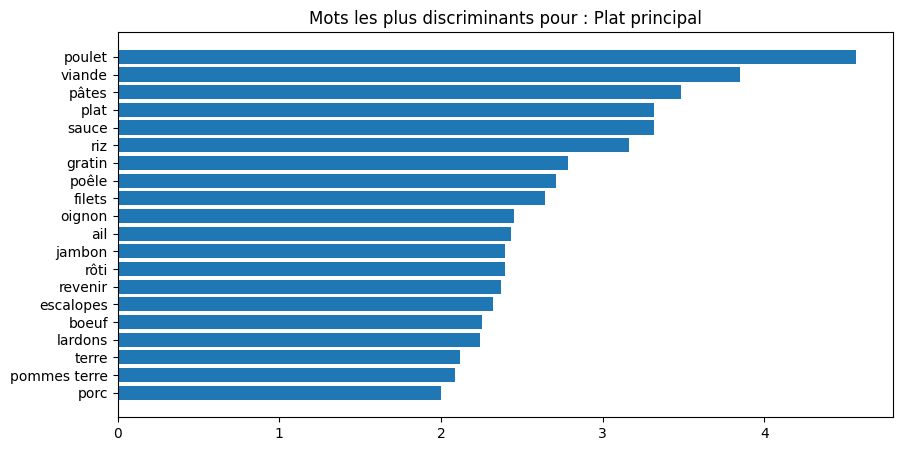

In [11]:
# Analyse des mots les plus discriminants pour chaque classe

def plot_top_words(model, feature_names, n_top_words):
    # On récupère les n_top_words plus grands coefficients pour chaque classe et on les affiche
    for i, class_name in enumerate(model.classes_):
        coeffs = model.coef_[i][:len(feature_names)]
        top_indices = coeffs.argsort()[-n_top_words:]
        plt.figure(figsize=(10, 5))
        plt.barh([feature_names[j] for j in top_indices], coeffs[top_indices])
        plt.title(f"Mots les plus discriminants pour : {class_name}")
        plt.show()

tfidf = model.named_steps['features'].named_transformers_['tfidf']
logreg = model.named_steps['logreg']
feature_names = tfidf.get_feature_names_out()

plot_top_words(logreg, feature_names,20)

#### Analyse qualitative
Certains mots discriminants pour les plats sont parfois présents dans les entrées comme "pâtes" ou "jambon". De même pour des mots comme "soupe" pour les entrées. Cela conduit souvent à une mauvaise classification. 

Certaines recettes sont aussi ambiguës comme la "Tarte au brocolis et au bleus" qui peut être considérée comme un plat principal ou une entrée.

Les entrées ont généralement moins d'ingrédients et des recettes moins longues que les plats, comme vu dans l'exploration. Le model semble faire des erreurs dès que l'entrée est consistante (tartes, cakes) ou que le plat est léger (soupes).

Le modèle de la méthode C nous donne de bons résultats. L'utilisation de TF-IDF permet de bien reconnaître le lexique des différents type de recettes (surtout des desserts). L'ajout de variables numériques (nombre d'ingrédients et longueur de la recette) apporte d'autres informations. Grâce au MinMaxScaler, ces indicateurs sont mis à l'échelle pour peser autant que les mots dans le modèle. Cette approche permet à la Régression Logistique de ne pas distinguer les catégories seulement par leur vocabulaire, un plat principal étant généralement plus long et complexe à préparer qu'une entrée. 